<a href="https://colab.research.google.com/github/Alister44/Analysis_Cafe_Sales/blob/main/analysis_cafe_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Analysis

*Cafe Sales - Dirty Data for Cleaning Training*

**Overview**  

The Dirty Cafe Sales dataset contains 10,000 rows of synthetic data representing sales transactions in a cafe. This dataset is intentionally "dirty," with missing values, inconsistent data, and errors introduced to provide a realistic scenario for data cleaning and exploratory data analysis (EDA). It can be used to practice cleaning techniques, data wrangling, and feature engineering.  

File Information  
File Name: dirty_cafe_sales.csv  
Number of Rows: 10,000  
Number of Columns: 8  


- `Transaction ID`	A unique identifier for each transaction. Always present and unique.	TXN_1234567
- `Item`	The name of the item purchased. May contain missing or invalid values (e.g., "ERROR").	Coffee, Sandwich
- `Quantity`	The quantity of the item purchased. May contain missing or invalid values.	1, 3, UNKNOWN
- `Price` Per Unit	The price of a single unit of the item. May contain missing or invalid values.	2.00, 4.00
- `Total Spent`	The total amount spent on the transaction. Calculated as Quantity * Price Per Unit.	8.00, 12.00
- `Payment Method`	The method of payment used. May contain missing or invalid values (e.g., None, "UNKNOWN").	Cash, Credit Card
- `Location`	The location where the transaction occurred. May contain missing or invalid values.	In-store, Takeaway
- `Transaction Date`	The date of the transaction. May contain missing or incorrect values.	2023-01-01

In [1]:
!pip show numpy

Name: numpy
Version: 2.0.2
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: Copyright (c) 2005-2024, NumPy Developers.
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are
met:

    * Redistributions of source code must retain the above copyright
       notice, this list of conditions and the following disclaimer.

    * Redistributions in binary form must reproduce the above
       copyright notice, this list of conditions and the following
       disclaimer in the documentation and/or other materials provided
       with the distribution.

    * Neither the name of the NumPy Developers nor the names of any
       contributors may be used to endorse or promote products derived
       from this software without specific prior written permission.

THIS SOFTWARE IS PROVIDED BY THE COPYRI

In [2]:
!pip show pandas

Name: pandas
Version: 2.2.2
Summary: Powerful data structures for data analysis, time series, and statistics
Home-page: https://pandas.pydata.org
Author: 
Author-email: The Pandas Development Team <pandas-dev@python.org>
License: BSD 3-Clause License

Copyright (c) 2008-2011, AQR Capital Management, LLC, Lambda Foundry, Inc. and PyData Development Team
All rights reserved.

Copyright (c) 2011-2023, Open source contributors.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are met:

* Redistributions of source code must retain the above copyright notice, this
  list of conditions and the following disclaimer.

* Redistributions in binary form must reproduce the above copyright notice,
  this list of conditions and the following disclaimer in the documentation
  and/or other materials provided with the distribution.

* Neither the name of the copyright holder nor the names of its
  contributors may be u

In [3]:
!pip show matplotlib

Name: matplotlib
Version: 3.10.0
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later

 1. This LICENSE AGREEMENT is between the Matplotlib Development Team
 ("MDT"), and the Individual or Organization ("Licensee") accessing and
 otherwise using matplotlib software in source or binary form and its
 associated documentation.

 2. Subject to the terms and conditions of this License Agreement, MDT
 hereby grants Licensee a nonexclusive, royalty-free, world-wide license
 to reproduce, analyze, test, perform and/or display publicly, prepare
 derivative works, distribute, and otherwise use matplotlib
 alone or in any derivative version, provided, however, that MDT's
 License Agreement and MDT's notice of copyright, i.e., "Copyright (c)
 2012- Matplotlib Development Team; All Rights Reserved" are retained in
 matplotlib

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:

# File path

# FILE_IN = "data/cafe_sales.csv"
FILE_IN = 'https://raw.githubusercontent.com/Alister44/Analysis_Cafe_Sales/refs/heads/main/data/dirty_cafe_sales.csv'

# FILE_OUT = "data/cafe_sales_clean.csv"
FILE_OUT = "cafe_sales_clean.csv"

In [6]:

df_origin = pd.read_csv(FILE_IN)



In [7]:
df = df_origin.copy()


# Primary Diagnosis

In [8]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [9]:
print("type: \n")
df.dtypes

type: 



,0
Transaction ID,object
Item,object
Quantity,object
Price Per Unit,object
Total Spent,object
Payment Method,object
Location,object
Transaction Date,object


Problem  
- Numeric columns(Quantity, Price, Total Spent)
- Date columns (Transaction Date)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [11]:
print("Missing values \n")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({
    'count': missing,
    '%': missing_pct
})
missing_report[missing_report['count']>0]

Missing values 



,count,%
Item,333,3.3
Quantity,138,1.4
Price Per Unit,179,1.8
Total Spent,173,1.7
Payment Method,2579,25.8
Location,3265,32.6
Transaction Date,159,1.6


In [12]:
print("Unique values:\n")

print("Item\n")
display(df['Item'].value_counts(dropna=False))

print("\n Payment Method \n")
display(df['Payment Method'].value_counts(dropna=False))
print("")

Unique values:

Item



,count
Item,
Juice,1171
Coffee,1165
Salad,1148
Cake,1139
Sandwich,1131
Smoothie,1096
Cookie,1092
Tea,1089
UNKNOWN,344



 Payment Method 



,count
Payment Method,
NaN,2579
Digital Wallet,2291
Credit Card,2273
Cash,2258
ERROR,306
UNKNOWN,293


In [13]:
print("Find lines with 'Error' or 'Unknown' \n")

mask_error = df.isin(['ERROR','UNKNOWN']).any(axis=1)
mask_error.sum()

df.isin(['ERROR','UNKNOWN']).sum()

Find lines with 'Error' or 'Unknown' 



,0
Transaction ID,0
Item,636
Quantity,341
Price Per Unit,354
Total Spent,329
Payment Method,599
Location,696
Transaction Date,301


Замість True/False записати количество 'ERROR','UNKNOWN' в каждом столбике

## Data Cleaning  
Якщо не зроблена копія датасету - тут необхідно створити!!!

`df_origin` - оригінальний датасет  
`df` - копія

In [14]:
print('Rename columns: \n')

df.columns = df.columns.str.strip()
df = df.rename(columns={
    'Transaction ID': 'transaction_id',
    'Item': 'item',
    'Quantity': 'quantity',
    'Price Per Unit': 'price_per_unit',
    'Total Spent': 'total_spent',
    'Payment Method': 'payment_method',
    'Location': 'location',
    'Transaction Date': 'transaction_date'
})
df.columns

Rename columns: 



Index(['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent',
       'payment_method', 'location', 'transaction_date'],
      dtype='object')

In [15]:
"_".join("  Transaction    ID   ".lower().split())

'transaction_id'

In [16]:
df.columns.str.lower().str.split()

Index([  ['transaction_id'],             ['item'],         ['quantity'],
         ['price_per_unit'],      ['total_spent'],   ['payment_method'],
               ['location'], ['transaction_date']],
      dtype='object')

In [17]:
df.replace(['ERROR', 'UNKNOWN', 'error', 'unknown', ''], np.nan, inplace=True)
# inplace=True заменяет значения в самой таблице
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    10000 non-null  object
 1   item              9031 non-null   object
 2   quantity          9521 non-null   object
 3   price_per_unit    9467 non-null   object
 4   total_spent       9498 non-null   object
 5   payment_method    6822 non-null   object
 6   location          6039 non-null   object
 7   transaction_date  9540 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [19]:
for col in ['quantity', 'price_per_unit', 'total_spent']:
    df[col] = pd.to_numeric(df[col],errors='coerce')

df.dtypes

,0
transaction_id,object
item,object
quantity,float64
price_per_unit,float64
total_spent,float64
payment_method,object
location,object
transaction_date,object


In [20]:
df['total_spent']

,total_spent
0,4.0
1,12.0
2,NaN
3,10.0
4,4.0
...,...
9995,4.0
9996,3.0
9997,8.0
9998,3.0


In [21]:
new_df = pd.DataFrame({"quantity": [0, 3, 5, '', np.nan, "q"]})
# display(new_df)
# new_df.info()
pd.to_numeric(new_df['quantity'], errors='coerce')

,quantity
0,0.0
1,3.0
2,5.0
3,NaN
4,NaN
5,NaN


In [22]:
#откатываем до оригинального столбца в случае перезаписи(ошибки)
df['transaction_date'] = df_origin['Transaction Date'].copy()

In [23]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'],errors='coerce')
df.dtypes

,0
transaction_id,object
item,object
quantity,float64
price_per_unit,float64
total_spent,float64
payment_method,object
location,object
transaction_date,datetime64[ns]


In [24]:
# Extracting time signatures
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['month_name'] = df['transaction_date'].dt.strftime('%B')
df['weekday'] = df['transaction_date'].dt.day_name()
df['week'] = df['transaction_date'].dt.isocalendar().week.astype('Int64')
df[['year','month','month_name','weekday','week']].head()

,year,month,month_name,weekday,week
0,2023.0,9.0,September,Friday,36
1,2023.0,5.0,May,Tuesday,20
2,2023.0,7.0,July,Wednesday,29
3,2023.0,4.0,April,Thursday,17
4,2023.0,6.0,June,Sunday,23




mask_recoverable — это булева серия (колонка из True/False) длиной как весь датафрейм. True только там, где можно восстановить значение.

In [25]:
#Restoring total_spent (quantity * price)
mask_recoverable = (
    df['total_spent'].isna() & # total_spent пропущен
    df['quantity'].notna() &   # quantity есть
    df['price_per_unit'].notna() # price_per_unit есть
)
df.loc[mask_recoverable,'total_spent'] = (df.loc[mask_recoverable,'quantity'] *
                                          df.loc[mask_recoverable,'price_per_unit'])
#записываем в total_spent результат умножения  quantity * price_per_unit
print(f"Restoring total_spent {mask_recoverable.sum()}")



Restoring total_spent 462


In [26]:
#dict of median prices
#восстанавливаем пропущенные цены через медиану
price_map = (
    df.dropna(subset=['item','price_per_unit'])
    .groupby('item')['price_per_unit']
    .median()
    .to_dict()
)
mask_price = df['price_per_unit'].isna() & df['item'].notna()
df.loc[mask_price,'price_per_unit'] = df.loc[mask_price,'item'].map(price_map)

print(f"Restoring price_per_unit {mask_price.sum()}")



Restoring price_per_unit 479


In [27]:
#Restoring total_spent (new price - median item)
mask_recoverable2 = (
    df['total_spent'].isna() & # total_spent пропущен
    df['quantity'].notna() &   # quantity есть
    df['price_per_unit'].notna() # price_per_unit есть
)
df.loc[mask_recoverable2,'total_spent'] = (df.loc[mask_recoverable2,'quantity'] *
                                          df.loc[mask_recoverable2,'price_per_unit'])
print(f"Restoring total_spent {mask_recoverable2.sum()} (new price - median item)")



Restoring total_spent 17 (new price - median item)


In [28]:
#fillna item -> moda
mode_item = df['item'].mode()[0]
#df['item'].fillna(mode_item, inplace=True)# old
df.fillna({'item': mode_item},inplace=True)

In [29]:
df.fillna(
    {
        'payment_method': 'Unknown',
        'location': 'Unknown'
    },
    inplace=True
)

In [30]:
# Delete transaction_date where NaT or Nan
befor = len(df)

df.dropna(subset=['transaction_date','quantity'], inplace=True)


after = len(df)
print(f"Deleted {befor - after} rows")

Deleted 914 rows


In [31]:
df.columns

Index(['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent',
       'payment_method', 'location', 'transaction_date', 'year', 'month',
       'month_name', 'weekday', 'week'],
      dtype='object')

In [32]:
df[['item', 'quantity', 'price_per_unit', 'total_spent',
       'payment_method', 'location', 'transaction_date', 'year', 'month',
       'month_name', 'weekday', 'week']].duplicated().sum()

np.int64(192)

In [33]:
#df.info()
(df['total_spent'] <= 0).sum()# проверка что не может быть отрицательных данных в числовых полях



np.int64(0)

In [34]:
#Restoring price_per_unit (total_spent / quantity)
mask_recoverable3 = (
    df['total_spent'].notna() & # total_spent пропущен
    df['quantity'].notna() &   # quantity есть
    df['price_per_unit'].isna() # price_per_unit есть
)

df.loc[mask_recoverable3,'price_per_unit'] = df.loc[mask_recoverable3,'total_spent'] / df.loc[mask_recoverable3,'quantity']
print(f"Restoring price_per_unit: {mask_recoverable3.sum()} (total_spent / quantity)")

Restoring price_per_unit: 45 (total_spent / quantity)


In [35]:
df.dropna(subset='total_spent',inplace=True)
print("Delete rows with Nan  df['total_spent'].notna() & df['price_per_unit'].notna()")

Delete rows with Nan  df['total_spent'].notna() & df['price_per_unit'].notna()


In [36]:
df.isna().sum().sum()

np.int64(0)

In [37]:
mask_total_spent = (df.quantity * df.price_per_unit != df.total_spent)
print(f"Uncorrect rows total_spent {mask_total_spent.sum()}")

Uncorrect rows total_spent 0


In [38]:
#Text fields are standartized
for col in ['item', 'payment_method', 'location']:
    df[col] = df[col].str.strip().str.title()
print("Text fields are standartized (Title Case)")

Text fields are standartized (Title Case)


# Cleaning results

In [39]:
print("Cleaning results: \n")

print(f"Rows before: {len(df_origin)}")
print(f"Rows after: {len(df)}")
print(f"Loss: {len(df_origin) - len(df)} ({(len(df_origin) - len(df))/len(df_origin) * 100:.1f}%)")

Cleaning results: 

Rows before: 10000
Rows after: 9083
Loss: 917 (9.2%)


In [40]:
print(f"----Residual gaps----")
remaining = df.isna().sum()
print(remaining[remaining>0] if remaining.any() else "No gaps")

print("---Data types after cleanup:---")
display(df.dtypes)

print("---Statistics:---")
print(df[['quantity','price_per_unit','total_spent']].describe().round(2))

----Residual gaps----
No gaps
---Data types after cleanup:---


,0
transaction_id,object
item,object
quantity,float64
price_per_unit,float64
total_spent,float64
payment_method,object
location,object
transaction_date,datetime64[ns]
year,float64
month,float64


---Statistics:---
       quantity  price_per_unit  total_spent
count   9083.00         9083.00      9083.00
mean       3.03            2.95         8.93
std        1.42            1.28         6.00
min        1.00            1.00         1.00
25%        2.00            2.00         4.00
50%        3.00            3.00         8.00
75%        4.00            4.00        12.00
max        5.00            5.00        25.00


Feature Engineering

In [41]:
#Season
season_map = {
    12: 'Winter',
    1: 'Winter',
    2: 'Winter',
    3: 'Spring',
    4: 'Spring',
    5: 'Spring',
    6: 'Summer',
    7: 'Summer',
    8: 'Summer',
    9: 'Autumn',
    10: 'Autumn',
    11: 'Autumn',
}
df['season'] = df['month'].map(season_map)


In [42]:
# is weekend
df['is_weekend'] = df['weekday'].isin(['Saturday','Sunday'])


In [43]:
#Check amount category
df['spend_tier'] = pd.cut(
    df['total_spent'],
    bins=[0,5,10,20,1000],
    labels=['Low','Medium','High','Premium']
)


In [44]:
print("New attributes: season, is_weekend, spend_tier")

New attributes: season, is_weekend, spend_tier


In [45]:
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,year,month,month_name,weekday,week,season,is_weekend,spend_tier
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023.0,9.0,September,Friday,36,Autumn,False,Low
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-Store,2023-05-16,2023.0,5.0,May,Tuesday,20,Spring,False,High
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-Store,2023-07-19,2023.0,7.0,July,Wednesday,29,Summer,False,Low
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27,2023.0,4.0,April,Thursday,17,Spring,False,Medium
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-Store,2023-06-11,2023.0,6.0,June,Sunday,23,Summer,True,Low


##Fast EDA(verification graphs)

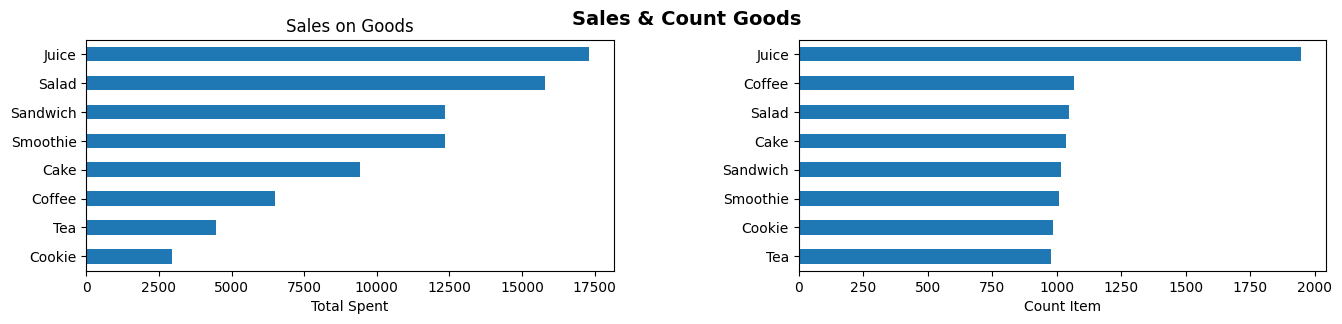

In [46]:
fig, axes = plt.subplots(1,2,figsize=(16,3))
fig.suptitle("Sales & Count Goods",fontsize=14,fontweight='bold')
plt.subplots_adjust(hspace=0.45,wspace=0.35)

#total_spent per item
ax = axes[0] # ax = axes[0,0]
df.groupby('item')['total_spent'].sum().sort_values().plot(kind='barh',ax=ax)
ax.set_title("Sales on Goods")
ax.set_xlabel("Total Spent")
ax.set_ylabel("")

#count per item
ax = axes[1] # ax = axes[0,1]
df['item'].value_counts().sort_values().plot(kind='barh',ax=ax)
ax.set_xlabel("Count Item")
ax.set_ylabel("")


plt.show()

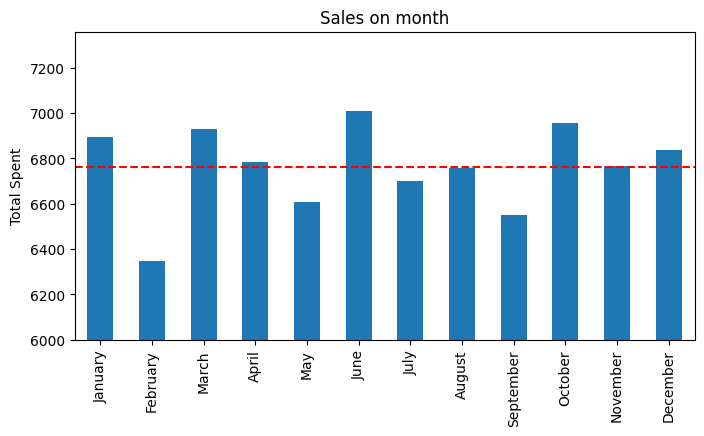

In [47]:
#Sales on month
fig = plt.figure(figsize=(8,4))
month_order = ['January','February','March','April','May','June', 'July', 'August','September','October','November','December']

#df.groupby('month_name')['total_spent'].sum()
rev_month = df.groupby('month_name')['total_spent'].sum().reindex(
    [m for m in month_order if m in df['month_name'].unique()]
)

rev_month.plot(
    kind='bar'
)

mean_value = rev_month.mean()
# std_value = rev_month.std()
# std_pct = (std_value/mean_value) * 100

plt.axhline(y=mean_value,color='red',linestyle='--',linewidth=1.5,label=f'Mean: {mean_value:.1f}')

plt.ylim(bottom=6000)
plt.title("Sales on month")
plt.xlabel("")
plt.ylabel("Total Spent")
# plt.legend(bbox_to_anchor=(1.25,1),loc='upper right')

# plt.text(1.02,0.6,f"std: {std_pct:.2f}%",transform=plt.gca().transAxes,
#          bbox=dict(boxstyle='round, pad=0.3',facecolor='white',alpha=0.7)
#          )

plt.show()

ДЗ: додати графіки за власним поглядом

In [48]:

plt.savefig('cafe_eda.png',dpi=150,bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [49]:
#шпаргалка
import calendar

print([calendar.month_name[i] for i in range(1,13)])

['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']


## Saving a clean CSV for Tableau


In [52]:
#шпаргалка
q = 0
try:
  a = 1 / 1
  q = 1
except Exception as e:
  print("Error:", e)
else:
  print("Спроба ділення")
finally:
  if q:
    print("Виконався try")
  else:
    print("Виконався except")

Спроба ділення
Виконався try


In [53]:
# For Tableau better date format: YYYY-MM-DD
try:
    df['transaction_date'] = df['transaction_date'].dt.strftime('%Y-%m-%d')
except:
    print("transaction date was changed - ('%Y-%m-%d') \n")

# For Tableau: bool -> str
df['is_weekend'] = df['is_weekend'].map({
    True: 'Yes',
    False: 'No'
})

df.to_csv(FILE_OUT, index=False, encoding='utf-8-sig')

print(f"Saved: {FILE_OUT}")  # work in colab ('data/file_name.csv')
print(f"Rows: {len(df)} | Columns: {df.shape[1]}")
print(f"Columns: {list(df.columns)}")


transaction date was chenged - ('%Y-%m-%d') 

Saved: cafe_sales_clean.csv
Rows: 9083 | Columns: 16
Columns: ['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date', 'year', 'month', 'month_name', 'weekday', 'week', 'season', 'is_weekend', 'spend_tier']


##Summaty Report

In [78]:
print(f"Total Revenue          {df['total_spent'].sum():>14,.2f}")
print(f"Number of transactions:{len(df):>14,}")
print(f"Average check          {df['total_spent'].mean():>14,.2f}")
print(f"Median check           {df['total_spent'].median():>14,.2f}")
print(f"Unique products        {df['item'].nunique():14,}")

all_location = df.loc[df['location'] != 'Unknown', 'location']
print(f"Unique locations       {all_location.nunique():14,}")

top_item = df.groupby('item')['total_spent'].sum().idxmax()
print(f"Top profitable product {top_item:>14}")

top_pay = df.loc[df['payment_method'] != "Unknown",'payment_method'].value_counts().idxmax()

print(f"Unique payment method  {df['payment_method'].nunique():>14,}")
print(f"Top payment method     {top_pay:>14}")
#

Total Revenue               81,140.00
Number of transactions:         9,083
Average check                    8.93
Median check                     8.00
Unique products                     8
Unique locations                    2
Top profitable product          Juice
Unique payment method               4
Top payment method     Digital Wallet
